## Objetivo

Neste notebook, realizamos a **análise exploratória dos dados (EDA — Exploratory Data Analysis)** do dataset clientes_sinteticos.csv.
O objetivo é compreender a estrutura dos dados, suas distribuições, relações entre variáveis e padrões que possam influenciar a inadimplência dos clientes bancários.

---

## Etapas principais

---

### 1. Configuração do ambiente

- O notebook é compatível com **Google Colab e VS Code**.
- Detecta automaticamente o ambiente de execução e define os caminhos corretos para leitura e salvamento dos arquivos.
- As pastas **data/** e **resultados/** são verificadas ou criadas automaticamente.

---

### 2. Carregamento e verificação do dataset

- Leitura do arquivo **clientes_sinteticos.csv**.
- Exibição das primeiras linhas e dimensões do conjunto de dados.
- Geração e salvamento das estatísticas descritivas em **resultados/estatisticas_descritivas.csv**.

---

### 3. Análise da variável-alvo (inadimplente)

- Cálculo da distribuição percentual de clientes inadimplentes e não inadimplentes.
- Salvamento dessa distribuição em **resultados/distribuicao_inadimplencia.csv**.

---

### 4. Visualizações gráficas

- **Distribuição da variável-alvo:**

- Gráfico de barras mostrando a quantidade de clientes inadimplentes e não inadimplentes.
(Salvo como **distribuicao_inadimplentes.png**)

- **Distribuições e Boxplots:**

- Distribuição do score de crédito e da renda mensal;
- Boxplots relacionando essas variáveis com a inadimplência;
(Salvo como **distribuicoes_boxplots.png**)

- **Mapa de Correlação:**

- Exibe o grau de correlação entre todas as variáveis numéricas;
- Útil para identificar possíveis redundâncias e relações importantes entre variáveis preditoras e a inadimplência;
(Salvo como **mapa_correlacao.png**)

---

### 5. Exportação dos resultados

- Todas as estatísticas e gráficos são exportados automaticamente para a pasta **resultados/** para uso nas próximas etapas do projeto.

---

### Resultado esperado

Ao final da execução deste notebook, o usuário terá:

- Um resumo estatístico completo do conjunto de dados;
- A distribuição da inadimplência na base;
- Visualizações que ajudam a entender o perfil dos clientes e o impacto de variáveis como renda e score de crédito;
- Um mapa de correlação que auxilia na escolha das variáveis mais relevantes para a modelagem preditiva.

In [1]:


# 1. Carregamento dos dados 

# Imports iniciais 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Detecta ambiente: Colab ou local
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    base_path = "/content/drive/MyDrive/agente-ia"
    print(" Executando no Google Colab.")
else:
    base_path = os.path.abspath("..")  # ajusta se o notebook estiver dentro de "notebooks/"
    print(" Executando localmente (VS Code).")

# Caminhos principais
data_path = os.path.join(base_path, "data")
results_path = os.path.join(base_path, "resultados")

# Cria pasta de resultados se não existir
os.makedirs(results_path, exist_ok=True)
print(f" Pasta de resultados verificada/criada em: {results_path}")

# Verifica se o arquivo de dados existe
file_path = os.path.join(data_path, "clientes_sinteticos.csv")
if not os.path.exists(file_path):
    raise FileNotFoundError(f" Arquivo não encontrado em: {file_path}")
print(f" Dataset encontrado em: {file_path}")

# Configurações de visualização 
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set(style="whitegrid", palette="pastel")

# Leitura do dataset 
df = pd.read_csv(file_path)
print(" Dataset carregado com sucesso!")
print("Dimensões:", df.shape)
display(
df.head())


 Executando localmente (VS Code).
 Pasta de resultados verificada/criada em: c:\Users\Nycolle\agente-ia\resultados
 Dataset encontrado em: c:\Users\Nycolle\agente-ia\data\clientes_sinteticos.csv
 Dataset carregado com sucesso!
Dimensões: (5000, 10)


,client_id,idade,renda_mensal,tempo_emprego_anos,qtd_contas,score_credito,historico_atrasos,valor_emprestimo,parcelas,inadimplente
0,1,56,"4,889.23",1.90,2,459.13,0,"35,015.27",35,0
1,2,69,"2,525.05",1.20,1,528.32,1,"9,833.68",59,1
2,3,46,"4,929.04",1.90,1,588.11,1,"5,009.69",21,0
3,4,32,"1,079.75",2.80,3,374.04,1,"5,282.45",33,0
4,5,60,"1,708.66",12.80,3,676.90,1,"38,535.48",20,1


In [2]:
# Estatísticas descritivas
desc = df.describe()
display(desc)

# Salva estatísticas descritivas
desc_path = os.path.join(results_path, "estatisticas_descritivas.csv")
desc.to_csv(desc_path)
print(f" Estatísticas descritivas salvas em: {desc_path}")

,client_id,idade,renda_mensal,tempo_emprego_anos,qtd_contas,score_credito,historico_atrasos,valor_emprestimo,parcelas,inadimplente
count,"5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00"
mean,"2,500.50",46.15,"4,025.95",3.01,2.04,600.13,0.49,"25,130.32",31.12,0.24
std,"1,443.52",16.33,"3,689.35",3.01,1.42,97.69,0.71,"14,412.83",16.33,0.43
min,1.00,18.00,169.75,0.00,0.00,300.00,0.00,504.63,3.00,0.00
25%,"1,250.75",32.00,"1,704.77",0.90,1.00,531.66,0.00,"12,358.90",17.00,0.00
50%,"2,500.50",46.00,"2,900.64",2.10,2.00,601.15,0.00,"24,982.87",31.00,0.00
75%,"3,750.25",60.00,"5,051.88",4.20,3.00,666.38,1.00,"37,850.32",45.00,0.00
max,"5,000.00",74.00,"39,819.47",24.10,9.00,850.00,5.00,"49,998.62",59.00,1.00


 Estatísticas descritivas salvas em: c:\Users\Nycolle\agente-ia\resultados\estatisticas_descritivas.csv



Distribuição da variável 'inadimplente':
inadimplente
0   75.74
1   24.26
Name: proportion, dtype: float64
 Distribuição de inadimplentes salva em: c:\Users\Nycolle\agente-ia\resultados\distribuicao_inadimplencia.csv


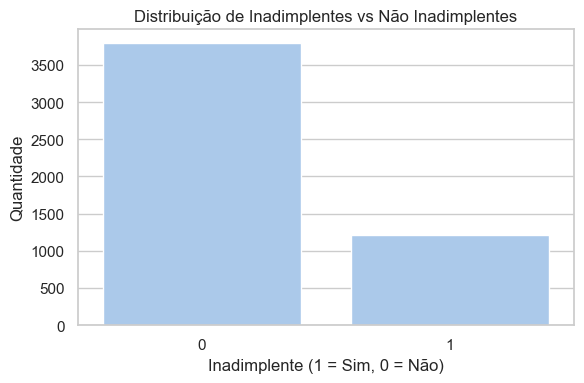

 Gráfico salvo em: c:\Users\Nycolle\agente-ia\resultados\distribuicao_inadimplentes.png


In [3]:
# Distribuição da variável alvo
print("\nDistribuição da variável 'inadimplente':")
dist_inad = df["inadimplente"].value_counts(normalize=True) * 100
print(dist_inad)

# Salva distribuição da variável alvo
dist_path = os.path.join(results_path, "distribuicao_inadimplencia.csv")
dist_inad.to_csv(dist_path, header=["percentual"])
print(f" Distribuição de inadimplentes salva em: {dist_path}")

# Gráficos

# 1️ Distribuição da variável alvo
plt.figure(figsize=(6, 4))
sns.countplot(x="inadimplente", data=df)
plt.title("Distribuição de Inadimplentes vs Não Inadimplentes")
plt.xlabel("Inadimplente (1 = Sim, 0 = Não)")
plt.ylabel("Quantidade")
plt.tight_layout()
fig_path = os.path.join(results_path, "distribuicao_inadimplentes.png")
plt.savefig(fig_path)
plt.show()
print(f" Gráfico salvo em: {fig_path}")


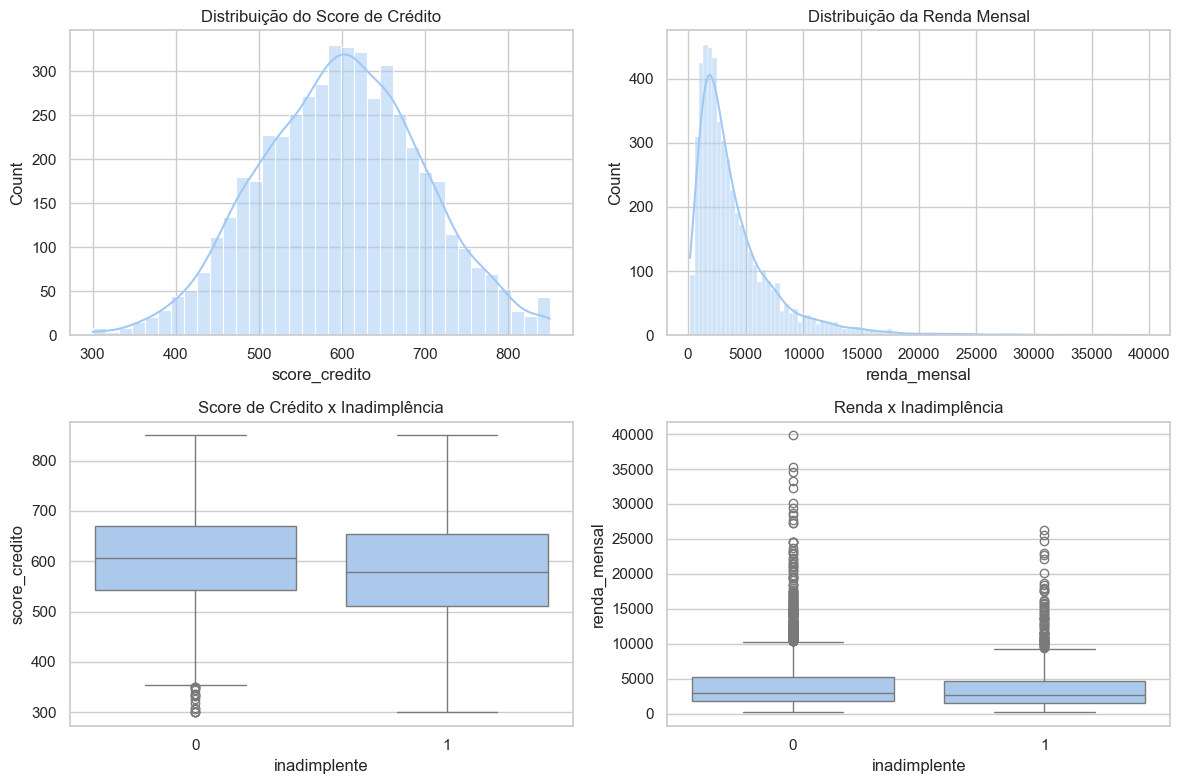

 Gráfico salvo em: c:\Users\Nycolle\agente-ia\resultados\distribuicoes_boxplots.png


In [4]:
# 2️ Distribuições e Boxplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df["score_credito"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribuição do Score de Crédito")

sns.histplot(df["renda_mensal"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Distribuição da Renda Mensal")

sns.boxplot(x="inadimplente", y="score_credito", data=df, ax=axes[1, 0])
axes[1, 0].set_title("Score de Crédito x Inadimplência")

sns.boxplot(x="inadimplente", y="renda_mensal", data=df, ax=axes[1, 1])
axes[1, 1].set_title("Renda x Inadimplência")

plt.tight_layout()
fig_path2 = os.path.join(results_path, "distribuicoes_boxplots.png")
plt.savefig(fig_path2)
plt.show()
print(f" Gráfico salvo em: {fig_path2}")


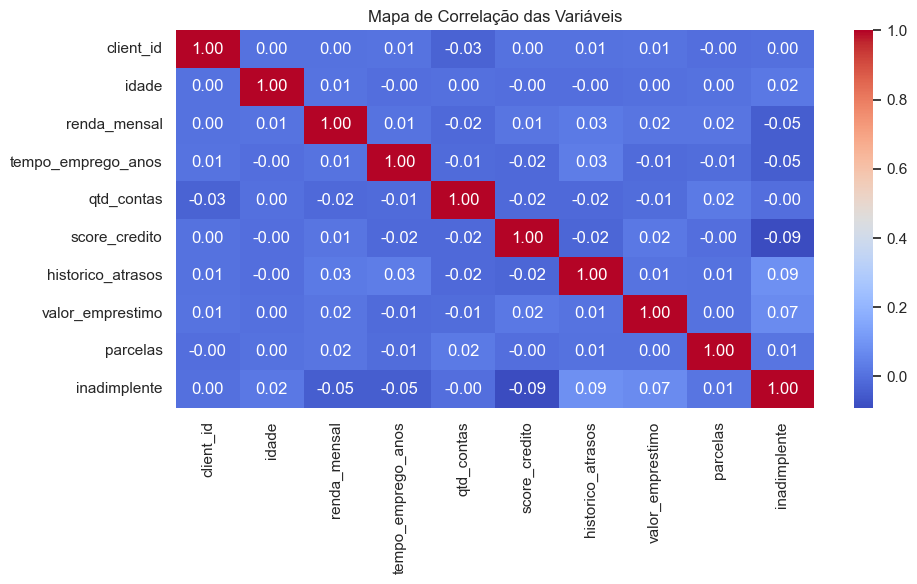

 Gráfico salvo em: c:\Users\Nycolle\agente-ia\resultados\mapa_correlacao.png

 Todos os resultados foram gerados e salvos com sucesso!


In [5]:
# 3️ Mapa de Correlação
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de Correlação das Variáveis")
plt.tight_layout()
fig_path3 = os.path.join(results_path, "mapa_correlacao.png")
plt.savefig(fig_path3)
plt.show()
print(f" Gráfico salvo em: {fig_path3}")

print("\n Todos os resultados foram gerados e salvos com sucesso!")
